In [72]:
# conda create --name bcitoolbox python=3.10

from bcitoolbox_local import simulateVV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from helpers import get_best_models, print_parameters

location = 'visible'

In [12]:
strategy_map = {
    'Averaging': 'ave',
    'Selection': 'sel',
    'Matching': 'mat',
}

vis_col = '#6636a5'
resp_col = '#9b72cf'

groups = ['Low Vision', 'Sighted Control']
conditions = ['F0B0', 'F1B0', 'F1B1', 'F1B2']

def simulate_data(parameters, strategy_name, fitType, file_name,
                  modeling_data_path='csv/modeling/data/',
                  n_simulation=10000, biOnly=0):
    
    data_file_path = modeling_data_path + file_name
    behavior_data = np.loadtxt(data_file_path, delimiter=',')
    if len(behavior_data) < 10: return

    strategy = strategy_map.get(strategy_name[0])

    error, modelprop, dataprop, responsesSim, r2 = simulateVV(parameters, 
                                                              n_simulation, 
                                                              behavior_data, 
                                                              biOnly,
                                                              strategy, 
                                                              fitType,)

    return error, modelprop, dataprop, responsesSim, r2


In [13]:
# Simulate data for each subject
condition_map = None
best_models_df = get_best_models('bci', sigma_a=0.2)
# best_models_df = find_best_model_per_subject()
all_props = defaultdict(dict)

for location in [location]: 
    location_df = best_models_df[best_models_df['location'] == location]

    for index, row in location_df.iterrows():
        subject = row['subject_id']
        file_name = f"{subject}_{location}.csv"
        Strategies = [row['strategy']]
        FitType = row['fit_type']
        model = 'bci'

        if condition_map is None:
            behavior_data = np.loadtxt(f'csv/modeling/data/{file_name}', delimiter=',')
            stimuli = behavior_data[:, [0, 1]]
            condition_map = np.unique(stimuli, axis=0)
            print("condition_map.shape:", condition_map.shape)

        print("\n=======================================")
        print(f"Simulating data for {subject} at {location}")
        print("=======================================\n")

        parameters = [
            row['pcommon'],
            row['sigma_v'],
            row['sigma_a'],
            row['mu_p'],
            row['sigma_p'],            
        ]
        results = simulate_data(parameters, Strategies, FitType, file_name)

        if results is not None:
            error, modelprop, dataprop, responsesSim, r2 = results
            # store simulated data
            all_props[subject][location] = {
                'modelprop': modelprop,
                'dataprop': dataprop,
                'r2': r2
            }

            # Split modelprop and dataprop according to conditions
            for i, condition in enumerate(condition_map):
                all_props[subject][location][f'F{int(condition[0])}B{int(condition[1])}'] = {
                    'model': model,
                    'Visual model': modelprop[0, i, :],
                    'Visual response': dataprop[0, i, :],
                }

group_data = {
    'Low Vision': {cond: {'resp': [], 'mod': []} for cond in conditions},
    'Sighted Control': {cond: {'resp': [], 'mod': []} for cond in conditions}
}

for sid in all_props.keys():
    group = 'Low Vision' if sid.startswith('LV') else 'Sighted Control'
    for cond in conditions:
        if location in all_props[sid] and cond in all_props[sid][location]:
            group_data[group][cond]['resp'].append(all_props[sid][location][cond]['Visual response'])
            group_data[group][cond]['mod'].append(all_props[sid][location][cond]['Visual model'])

stats = {group: {cond: {} for cond in conditions} for group in groups}

condition_map.shape: (4, 2)

Simulating data for LV001 at visible

fit type = mll
===== DEBUG: fixed values = [0.5, 0.4, 0.8, 4000, 2, 0, 0] =====
===== DEBUG: pcommon = 0.9477094478728416 =====
===== DEBUG: sigma_v = 0.2617045322840552 =====
===== DEBUG: sigma_a = 0.2 =====
===== DEBUG: sigma_p = 1.5 =====
===== DEBUG: mu_p = 0.7113890609152548 =====
R2 on all
0.9135853285231906
Sum Loglike    Optimal
-267.1870657874542 -108.25294002413693
Explainable variance, r2:
0.8402884606635279

Simulating data for LV002 at visible

fit type = mll
===== DEBUG: fixed values = [0.5, 0.4, 0.8, 4000, 2, 0, 0] =====
===== DEBUG: pcommon = 0.9888691731854008 =====
===== DEBUG: sigma_v = 0.4480537607799024 =====
===== DEBUG: sigma_a = 0.2 =====
===== DEBUG: sigma_p = 1.5 =====
===== DEBUG: mu_p = 0.1148299025929374 =====
R2 on all
0.6517644885020075
Sum Loglike    Optimal
-391.3819039557113 -102.22954740549622
Explainable variance, r2:
0.4016688337914578

Simulating data for LV003 at visible

fit type 

<Figure size 640x480 with 0 Axes>

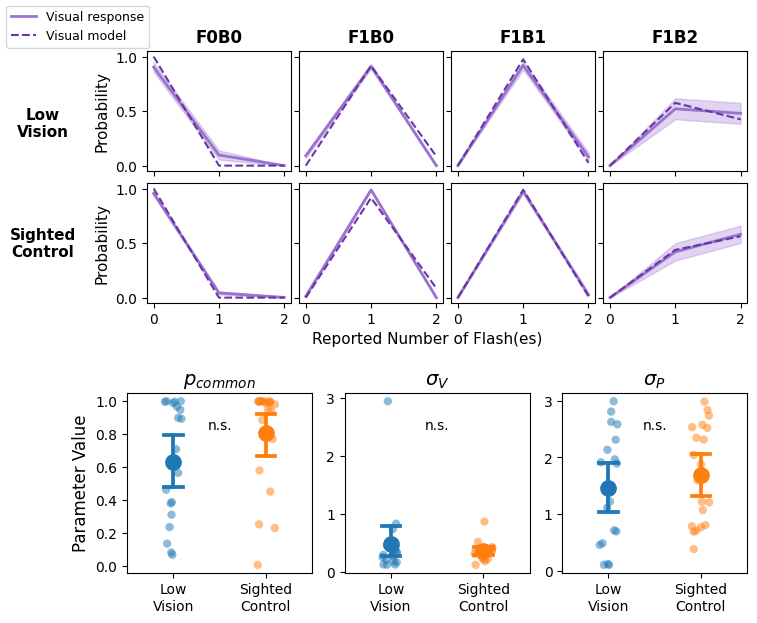

In [69]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(3, 12, height_ratios=[1, 1, 1.5], hspace=0.4, wspace=1)

gs_top = gridspec.GridSpec(2, 12, height_ratios=[1, 1], 
                           left=0.15, bottom=0.5, top=0.92, hspace=0.1)

gs_bottom = gridspec.GridSpec(1, 12, bottom=0.05, top=0.35, wspace=1.5)

axes_top = []
for r in range(2):
    row_axes = []
    for c in range(4):
        ax = fig.add_subplot(gs_top[r, c*3 : (c+1)*3])
        row_axes.append(ax)
    axes_top.append(row_axes)


axes_bottom = []
for i in range(3):
    ax = fig.add_subplot(gs_bottom[0, i*4 : (i+1)*4])
    axes_bottom.append(ax)

for row, group in enumerate(groups):
    for col, condition in enumerate(conditions):
        ax = axes_top[row][col]
        data = stats[group][condition]
        x = np.arange(len(data['resp_mean']))
        
        ax.plot(x, data['resp_mean'], color=resp_col, label='Visual response', lw=2)
        ax.fill_between(x, data['resp_mean'] - data['resp_sem'], 
                        data['resp_mean'] + data['resp_sem'], color=resp_col, alpha=0.3)
        
        ax.plot(x, data['mod_mean'], color=vis_col, linestyle='--', label='Visual model', lw=1.5)
        ax.set_ylim(-0.05, 1.05)
        
        if col == 0:
            ax.set_ylabel('Probability', fontsize=11)
        if col > 0:
            ax.set_yticklabels([])
        if row == 0:
            ax.set_title(condition, fontweight='bold')
        if row < 1:
            ax.set_xticklabels([])

# legend
handles, labels = axes_top[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', fontsize=9)


df = get_best_models(model='bci', sigma_a=0.2)
# only keep high-visibility fits
df = df[df['location']=='visible'].copy()
N = df['subject_id'].nunique()

param_groups = {
    'Prior': ['pcommon', 'sigma_p'],
    'Visual': ['sigma_v'],
    'Model': ['r2', 'bic']
}
all_parameters = [p for sublist in param_groups.values() for p in sublist]

tidy_df = df.melt(
    id_vars=['subject_id', 'group', 'strategy'],
    value_vars=all_parameters,
    var_name='parameter',
    value_name='value'
)

param_title = {
    "pcommon": r"$p_{common}$",
    "sigma_v": r"$\sigma_V$",
    "sigma_p": r"$\sigma_P$",
}


for i, p in enumerate(param_title.keys()):
    ax = axes_bottom[i]
    dp = tidy_df[tidy_df["parameter"] == p]    

    sns.pointplot(data=dp, x="group", y="value", hue="group", ax=ax,
                  linestyles='none', capsize=0.2, errorbar='ci', markers='o', markersize=10)
    
    sns.stripplot(data=dp, x="group", y="value", hue="group", ax=ax,
                  size=6, alpha=0.5, legend=False)

    ax.set_title(param_title[p], fontsize=14, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Low\nVision', 'Sighted\nControl'])

axes_bottom[0].set_ylabel("Parameter Value", fontsize=12)
axes_bottom[0].text(0.5, 0.8, 'n.s.', ha='center', transform=axes_bottom[0].transAxes)
axes_bottom[1].text(0.5, 0.8, 'n.s.', ha='center', transform=axes_bottom[1].transAxes)
axes_bottom[2].text(0.5, 0.8, 'n.s.', ha='center', transform=axes_bottom[2].transAxes)

fig.text(0.02, 0.8, 'Low\nVision', va='center', ha='center', fontweight='bold', fontsize=11)
fig.text(0.02, 0.6, 'Sighted\nControl', va='center', ha='center', fontweight='bold', fontsize=11)
fig.text(0.5, 0.44, 'Reported Number of Flash(es)', va='center', ha='center', fontsize=11)

plt.show()

In [75]:
param_df = print_parameters(model='bci', sigma_a=0.2, loc='visible')

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

best_df = get_best_models(model='bci', sigma_a=0.2)
best_df = best_df[best_df['location']=='visible'].copy()

parameters = ["pcommon", "sigma_v", "sigma_p", ]

pivot_df = best_df.pivot(index='subject_id', columns='group', values=parameters)
    
results = []

for param in parameters:
    group_control = best_df[best_df['group'] == 'Control'][param].dropna()
    group_lv = best_df[best_df['group'] == 'Low Vision'][param].dropna()
    
    stat, p_val = mannwhitneyu(group_control, group_lv, alternative='two-sided')
    
    results.append({
        'Parameter': param,
        'U_stat': stat,
        'p_raw': p_val,
        'N_Control': len(group_control),
        'N_LowVision': len(group_lv)
    })

stats_df = pd.DataFrame(results)
_, p_corr, _, _ = multipletests(stats_df['p_raw'], method='bonferroni')
stats_df['p_corrected'] = p_corr
stats_df['Significant'] = stats_df['p_corrected'] < 0.05

print("\n======== Mann-Whitney U Test Results ========")
# print(stats_df)
print(stats_df[['Parameter', 'N_Control', 'N_LowVision', 'U_stat', 'p_corrected', 'Significant']].to_string(index=False))


======== BCI Parameters (Mean ± SEM) =============
                pcommon      sigma_v      sigma_p
group                                            
Control     0.81 ± 0.07  0.35 ± 0.03  1.70 ± 0.18
Low Vision  0.63 ± 0.08  0.47 ± 0.14  1.45 ± 0.23

======== Mann-Whitney U Test Results ========
Parameter  N_Control  N_LowVision  U_stat  p_corrected  Significant
  pcommon         21           19   258.0     0.348639        False
  sigma_v         21           19   216.0     1.000000        False
  sigma_p         21           19   229.0     1.000000        False


In [76]:
# Low-Visibility locations???

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

param_df = print_parameters(model='bci', sigma_a=0.2, loc='invisible')

best_df = get_best_models(model='bci', sigma_a=0.2)
best_df = best_df[best_df['location']=='invisible'].copy()

parameters = ["pcommon", "sigma_v", "sigma_p", ]

pivot_df = best_df.pivot(index='subject_id', columns='group', values=parameters)
    
results = []

for param in parameters:
    group_control = best_df[best_df['group'] == 'Control'][param].dropna()
    group_lv = best_df[best_df['group'] == 'Low Vision'][param].dropna()
    
    stat, p_val = mannwhitneyu(group_control, group_lv, alternative='two-sided')
    
    results.append({
        'Parameter': param,
        'U_stat': stat,
        'p_raw': p_val,
        'N_Control': len(group_control),
        'N_LowVision': len(group_lv)
    })

stats_df = pd.DataFrame(results)
_, p_corr, _, _ = multipletests(stats_df['p_raw'], method='bonferroni')
stats_df['p_corrected'] = p_corr
stats_df['Significant'] = stats_df['p_corrected'] < 0.05

print("\n======== Mann-Whitney U Test Results ========")
# print(stats_df)
print(stats_df[['Parameter', 'N_Control', 'N_LowVision', 'U_stat', 'p_corrected', 'Significant']].to_string(index=False))


======== BCI Parameters (Mean ± SEM) =============
                pcommon      sigma_v      sigma_p
group                                            
Control     0.81 ± 0.13  1.17 ± 0.55  1.56 ± 0.59
Low Vision  0.53 ± 0.10  0.63 ± 0.21  1.53 ± 0.21

======== Mann-Whitney U Test Results ========
Parameter  N_Control  N_LowVision  U_stat  p_corrected  Significant
  pcommon          5           17    59.0     0.629645        False
  sigma_v          5           17    49.0     1.000000        False
  sigma_p          5           17    34.0     1.000000        False
